# Adult Income Prediction

## 1. Exploratory Data Analysis (EDA)
Phần này trình bày tổng quan dữ liệu, phân phối target, và một số đặc trưng quan trọng trước khi thực hiện preprocessing.

### 1.1. Load dataset
Dataset được tải từ nguồn công khai trên GitHub để notebook có thể chạy trực tiếp trên Google Colab.

In [ ]:
# [EDA 1.1] Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# [EDA 1.1] Load dataset from public GitHub URL
url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (48842, 15)
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-pe

### 1.2. Dataset overview
Phần này kiểm tra cấu trúc tổng quát của dữ liệu, bao gồm kiểu dữ liệu, thống kê mô tả, và phân loại sơ bộ giữa các cột số và cột phân loại.

In [ ]:
# [EDA 1.2] Display dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
# [EDA 1.2] Summary statistics for numerical columns
print(df.describe())

                age        fnlwgt  educational-num  capital-gain  \
count  48842.000000  4.884200e+04     48842.000000  48842.000000   
mean      38.643585  1.896641e+05        10.078089   1079.067626   
std       13.710510  1.056040e+05         2.570973   7452.019058   
min       17.000000  1.228500e+04         1.000000      0.000000   
25%       28.000000  1.175505e+05         9.000000      0.000000   
50%       37.000000  1.781445e+05        10.000000      0.000000   
75%       48.000000  2.376420e+05        12.000000      0.000000   
max       90.000000  1.490400e+06        16.000000  99999.000000   

       capital-loss  hours-per-week  
count  48842.000000    48842.000000  
mean      87.502314       40.422382  
std      403.004552       12.391444  
min        0.000000        1.000000  
25%        0.000000       40.000000  
50%        0.000000       40.000000  
75%        0.000000       45.000000  
max     4356.000000       99.000000  


In [ ]:
# [EDA 1.2] Summary statistics for categorical columns
print(df.describe(include='object'))

       workclass education      marital-status      occupation relationship  \
count      48842     48842               48842           48842        48842   
unique         9        16                   7              15            6   
top      Private   HS-grad  Married-civ-spouse  Prof-specialty      Husband   
freq       33906     15784               22379            6172        19716   

         race gender native-country income  
count   48842  48842          48842  48842  
unique      5      2             42      2  
top     White   Male  United-States  <=50K  
freq    41762  32650          43832  37155  


In [ ]:
# [EDA 1.2] Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


### 1.3. Missing value inspection
Trước khi xử lý dữ liệu, cần kiểm tra missing value theo chuẩn `NaN` và quan sát các giá trị bất thường trong các cột phân loại.

In [ ]:
# [EDA 1.3] Check missing values in standard NaN format
print(df.isnull().sum())

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [ ]:
# [EDA 1.3] Inspect common values in categorical columns
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].astype(str).str.strip().value_counts(dropna=False).head(10))


Column: workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Column: education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

Column: marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

Column: occupation
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales              

Kết quả cho thấy một số cột categorical xuất hiện giá trị `?`, cho thấy dữ liệu thiếu đang được mã hóa dưới dạng chuỗi thay vì `NaN`.

Vì vậy, ở bước preprocessing, nhóm sẽ cần chuẩn hóa các giá trị này về dạng missing value chuẩn trước khi thực hiện imputation.

In [ ]:
# [EDA 1.3] Count the number of '?' in each column
print((df == '?').sum())

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [ ]:
# [EDA 1.3] Calculate the percentage of '?' in each column
print(((df == '?').sum() / len(df) * 100).round(2))

age                0.00
workclass          5.73
fnlwgt             0.00
education          0.00
educational-num    0.00
marital-status     0.00
occupation         5.75
relationship       0.00
race               0.00
gender             0.00
capital-gain       0.00
capital-loss       0.00
hours-per-week     0.00
native-country     1.75
income             0.00
dtype: float64


### 1.4. Target distribution
Phần này kiểm tra phân phối của biến mục tiêu `income` để đánh giá mức độ cân bằng giữa các lớp.

In [ ]:
# [EDA 1.4] Inspect target values and class counts
print("Unique values of target:")
print(df['income'].unique())

print("\nClass counts:")
print(df['income'].value_counts())

print("\nClass percentages (%):")
print((df['income'].value_counts(normalize=True) * 100).round(2))

Unique values of target:
['<=50K' '>50K']

Class counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Class percentages (%):
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


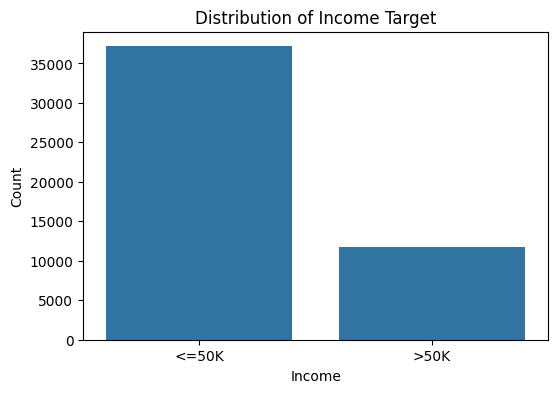

In [ ]:
# [EDA 1.4] Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='income')
plt.title('Distribution of Income Target')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

### 1.5. Categorical features by target
Phân tích một số biến phân loại tiêu biểu gồm `education`, `occupation`, và `marital-status` để quan sát sự khác biệt phân phối giữa hai nhóm thu nhập.

In [ ]:
# [EDA 1.5] Select categorical columns for analysis
selected_cat_cols = ['education', 'occupation', 'marital-status']

for col in selected_cat_cols:
    print(f"\n=== {col} ===")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False))


=== education ===
Number of unique values: 16
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

=== occupation ===
Number of unique values: 15
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
?                    2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

=== marital-status ===
Number of unique values: 7
marital-status
Married-civ-spouse      

Để quan sát rõ hơn sự khác biệt giữa hai nhóm thu nhập trong từng category, nhóm sử dụng bảng tỷ lệ theo hàng và biểu đồ cột chồng chuẩn hóa.

In [ ]:
# [EDA 1.5] Crosstab with row-wise proportions
for col in selected_cat_cols:
    print(f"\n=== {col} by income (proportion) ===")
    display(pd.crosstab(df[col], df['income'], normalize='index').round(3))


=== education by income (proportion) ===


income,<=50K,>50K
education,,
10th,0.937,0.063
11th,0.949,0.051
12th,0.927,0.073
1st-4th,0.968,0.032
5th-6th,0.947,0.053
7th-8th,0.935,0.065
9th,0.946,0.054
Assoc-acdm,0.742,0.258
Assoc-voc,0.747,0.253



=== occupation by income (proportion) ===


income,<=50K,>50K
occupation,,
?,0.906,0.094
Adm-clerical,0.863,0.137
Armed-Forces,0.667,0.333
Craft-repair,0.774,0.226
Exec-managerial,0.522,0.478
Farming-fishing,0.884,0.116
Handlers-cleaners,0.933,0.067
Machine-op-inspct,0.877,0.123
Other-service,0.959,0.041



=== marital-status by income (proportion) ===


income,<=50K,>50K
marital-status,,
Divorced,0.899,0.101
Married-AF-spouse,0.622,0.378
Married-civ-spouse,0.554,0.446
Married-spouse-absent,0.908,0.092
Never-married,0.955,0.045
Separated,0.935,0.065
Widowed,0.916,0.084


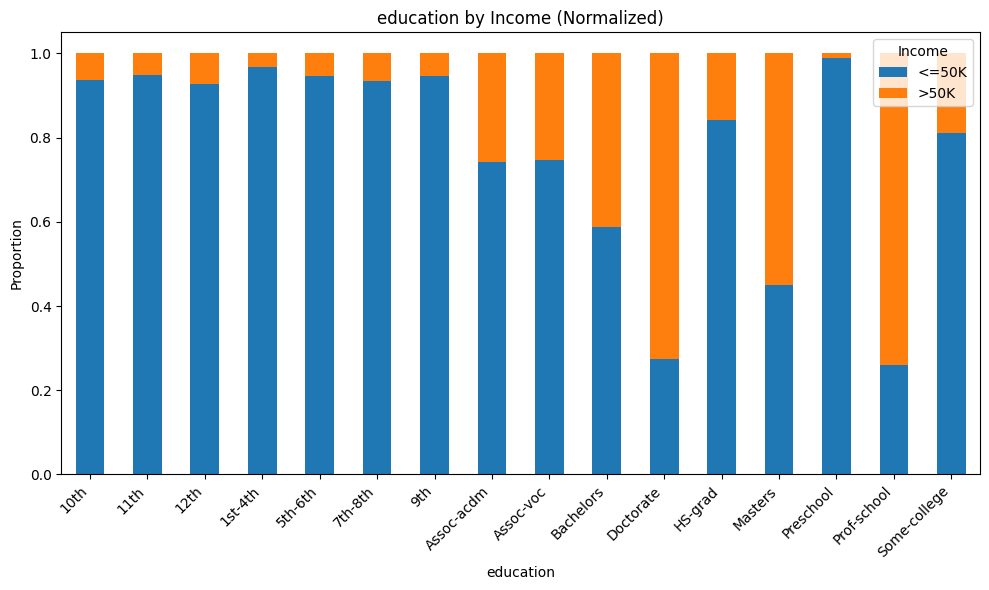

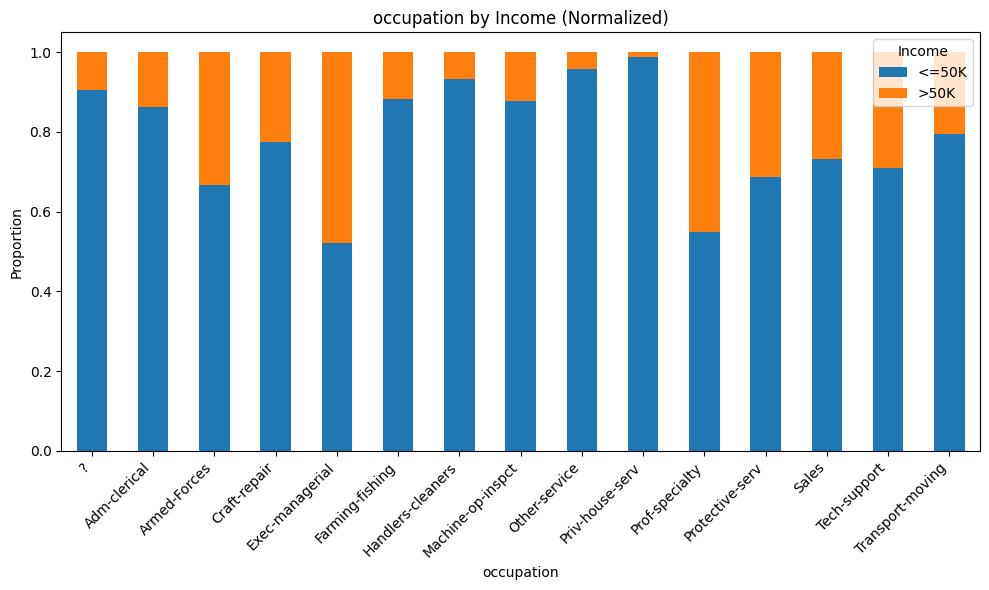

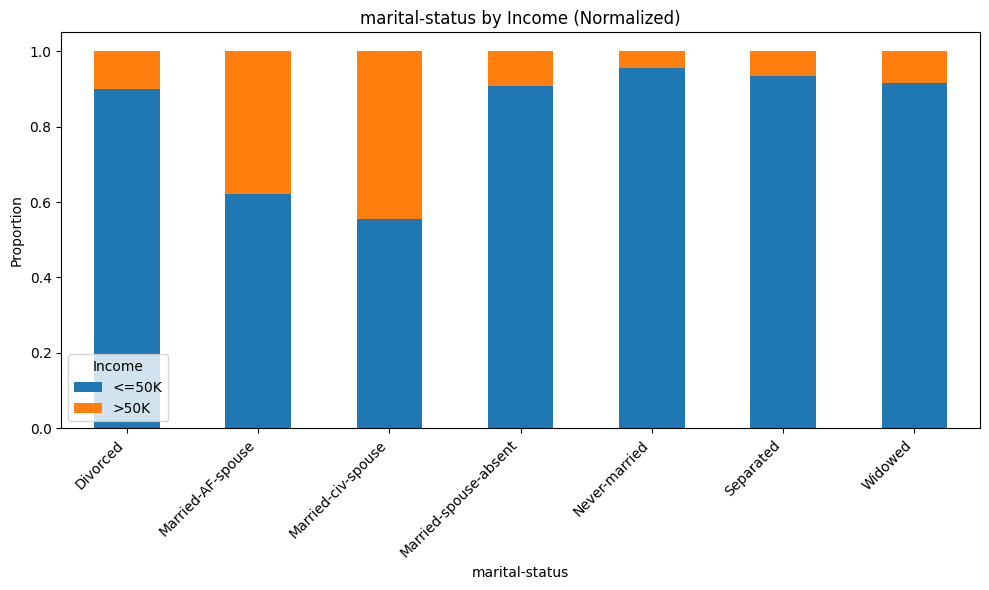

In [ ]:
# [EDA 1.5] Normalized stacked bar charts for selected categorical columns
for col in selected_cat_cols:
    crosstab_norm = pd.crosstab(df[col], df['income'], normalize='index')

    crosstab_norm.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'{col} by Income (Normalized)')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Income')
    plt.tight_layout()
    plt.show()

### 1.6. Numerical features by target
Phần này sử dụng boxplot để so sánh phân phối của một số biến số theo `income`.

In [ ]:
# [EDA 1.6] Select numerical columns for analysis
selected_num_cols = ['age', 'hours-per-week', 'educational-num']
print(df[selected_num_cols].describe())

                age  hours-per-week  educational-num
count  48842.000000    48842.000000     48842.000000
mean      38.643585       40.422382        10.078089
std       13.710510       12.391444         2.570973
min       17.000000        1.000000         1.000000
25%       28.000000       40.000000         9.000000
50%       37.000000       40.000000        10.000000
75%       48.000000       45.000000        12.000000
max       90.000000       99.000000        16.000000


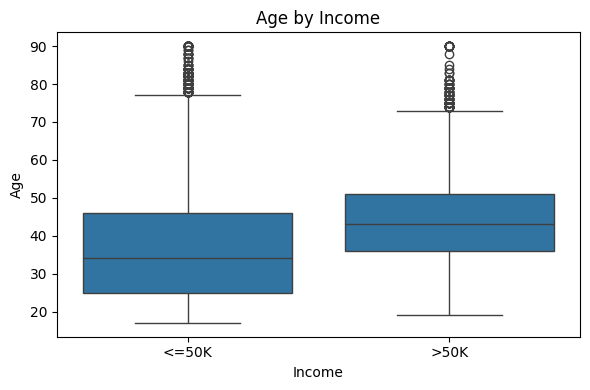

In [ ]:
# [EDA 1.6] Boxplot for age by income
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='income', y='age')
plt.title('Age by Income')
plt.xlabel('Income')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

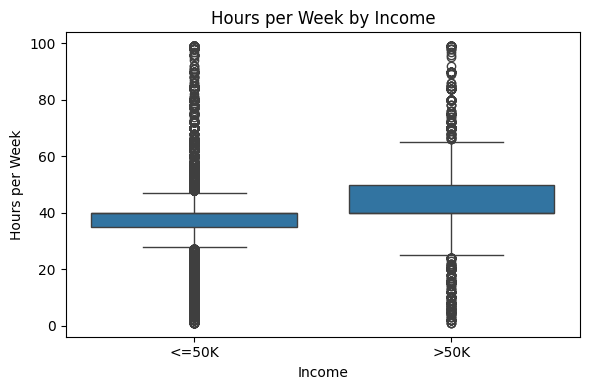

In [ ]:
# [EDA 1.6] Boxplot for hours-per-week by income
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Hours per Week by Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.tight_layout()
plt.show()

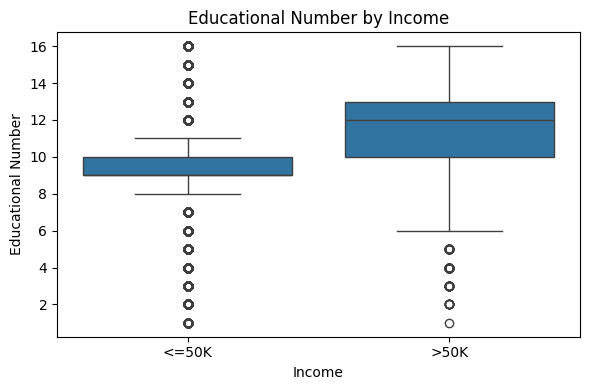

In [ ]:
# [EDA 1.6] Boxplot for educational-num by income
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='income', y='educational-num')
plt.title('Educational Number by Income')
plt.xlabel('Income')
plt.ylabel('Educational Number')
plt.tight_layout()
plt.show()

### 1.7. Distribution analysis for `capital-gain`
Phần này tập trung vào `capital-gain` vì biến này có phân phối lệch mạnh, tỷ lệ giá trị bằng 0 rất cao và xuất hiện một số giá trị lớn bất thường.

In [ ]:
# [EDA 1.7] Summary statistics for capital-gain
print(df['capital-gain'].describe())

count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64


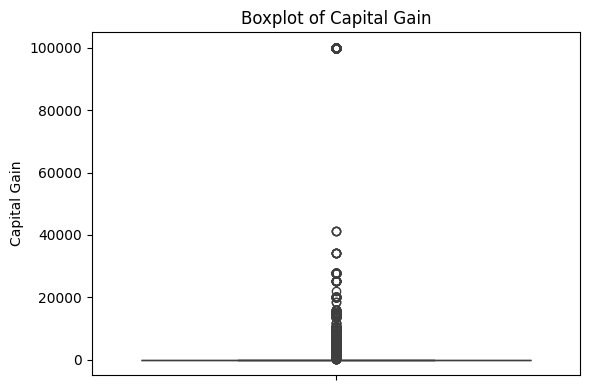

In [ ]:
# [EDA 1.7] Boxplot for capital-gain
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['capital-gain'])
plt.title('Boxplot of Capital Gain')
plt.ylabel('Capital Gain')
plt.tight_layout()
plt.show()

In [ ]:
# [EDA 1.7] Count zero and non-zero values in capital-gain
capital_gain_zero = (df['capital-gain'] == 0).sum()
capital_gain_nonzero = (df['capital-gain'] > 0).sum()

print("Number of zero values:", capital_gain_zero)
print("Number of non-zero values:", capital_gain_nonzero)
print("Percentage of zero values:", round(capital_gain_zero / len(df) * 100, 2), "%")

Number of zero values: 44807
Number of non-zero values: 4035
Percentage of zero values: 91.74 %


Do phần lớn giá trị bằng `0`, nhóm chỉ trực quan hóa phân phối của các giá trị `capital-gain > 0` để quan sát rõ hơn phần đuôi phân phối.

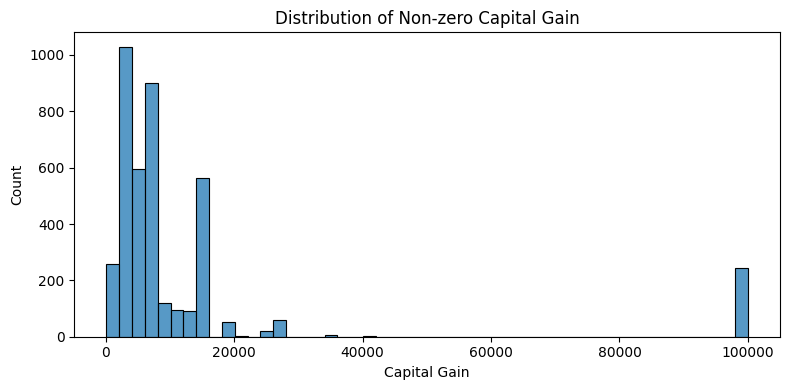

In [ ]:
# [EDA 1.7] Histogram for non-zero capital-gain values
plt.figure(figsize=(8, 4))
sns.histplot(df.loc[df['capital-gain'] > 0, 'capital-gain'], bins=50)
plt.title('Distribution of Non-zero Capital Gain')
plt.xlabel('Capital Gain')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 1.8. Correlation heatmap
Phần này trực quan hóa ma trận tương quan giữa các numerical features để quan sát mức độ liên hệ tuyến tính giữa các biến số.

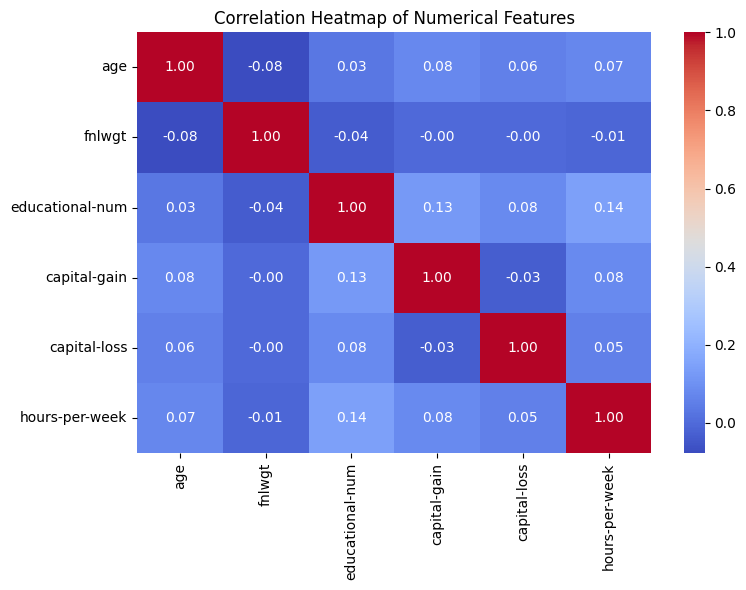

In [ ]:
# [EDA 1.8] Correlation matrix for numerical features
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

Kết quả cho thấy phần lớn numerical features chỉ có tương quan tuyến tính yếu với nhau, chưa xuất hiện cặp biến số nào có tương quan quá cao.

### 1.9. Relationship between `education` and `educational-num`
Phần này kiểm tra xem hai cột `education` và `educational-num` có đang biểu diễn cùng một thông tin hay không.

In [ ]:
# [EDA 1.9] Examine the relationship between education and educational-num
education_mapping = df.groupby('education')['educational-num'].unique().reset_index()
print(education_mapping)

       education educational-num
0           10th             [6]
1           11th             [7]
2           12th             [8]
3        1st-4th             [2]
4        5th-6th             [3]
5        7th-8th             [4]
6            9th             [5]
7     Assoc-acdm            [12]
8      Assoc-voc            [11]
9      Bachelors            [13]
10     Doctorate            [16]
11       HS-grad             [9]
12       Masters            [14]
13     Preschool             [1]
14   Prof-school            [15]
15  Some-college            [10]


Kết quả cho thấy mỗi mức của `education` tương ứng với đúng một giá trị của `educational-num`. Điều này cho thấy hai cột gần như mang cùng nội dung thông tin, chỉ khác cách biểu diễn.



### 1.10. Additional analysis of `capital-gain`
Ngoài phân phối và outlier, nhóm kiểm tra thêm mối liên hệ giữa `capital-gain` và target `income`.

In [ ]:
# [EDA 1.10] Compare zero vs non-zero capital-gain across income groups
capital_gain_flag = pd.crosstab(df['income'], df['capital-gain'] > 0, normalize='index').round(3)
print(capital_gain_flag)

capital-gain  False  True 
income                    
<=50K         0.958  0.042
>50K          0.787  0.213


Kết quả cho thấy tỷ lệ quan sát có `capital-gain > 0` ở nhóm `>50K` cao hơn đáng kể so với nhóm `<=50K`.

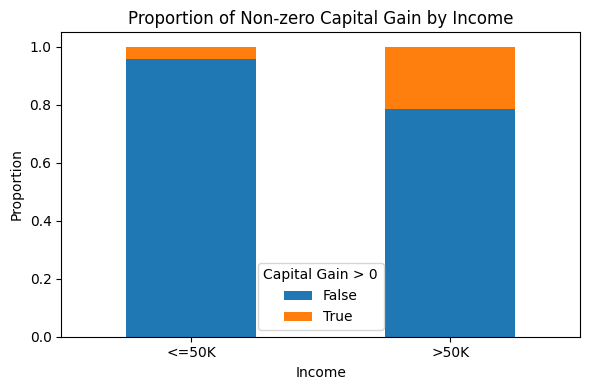

In [ ]:
# [EDA 1.10] Plot proportion of non-zero capital-gain by income
capital_gain_flag_plot = pd.crosstab(
    df['income'],
    df['capital-gain'] > 0,
    normalize='index'
).round(3)

capital_gain_flag_plot.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Proportion of Non-zero Capital Gain by Income')
plt.xlabel('Income')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Capital Gain > 0')
plt.tight_layout()
plt.show()

Biểu đồ củng cố nhận định rằng `capital-gain` có thể là một biến hữu ích cho bài toán phân loại thu nhập, dù bản thân biến này có phân phối rất lệch.


### 1.11. Additional check for `capital-loss`
Ngoài `capital-gain`, nhóm kiểm tra thêm `capital-loss` để đánh giá xem biến này có nên bị loại bỏ ngay ở bước preprocessing hay không.

In [ ]:
# [EDA 1.11] Check capital-loss before deciding whether to drop it
capital_loss_zero = (df['capital-loss'] == 0).sum()

print(f"Zero values: {capital_loss_zero} ({round(capital_loss_zero / len(df) * 100, 2)}%)")
print(pd.crosstab(df['income'], df['capital-loss'] > 0, normalize='index').round(3))

Zero values: 46560 (95.33%)
capital-loss  False  True 
income                    
<=50K         0.969  0.031
>50K          0.902  0.098


Kết quả cho thấy `capital-loss` có tỷ lệ giá trị bằng `0` rất cao, tuy nhiên tỷ lệ quan sát có giá trị khác `0` ở nhóm `>50K` vẫn cao hơn đáng kể so với nhóm `<=50K`. Vì vậy, biến này có thể vẫn mang thông tin hữu ích và chưa nên loại bỏ ngay chỉ dựa trên độ thưa của dữ liệu.